Fig. 2

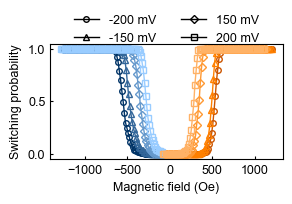

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    # 'xtick.major.pad': 3,
    # 'ytick.major.pad': 3,
})

file_path = './data/Fig2/Psw_H.xlsx'

voltage_list = ["-200 mV","-150 mV","150 mV","200 mV"]
marker_list = ['o','^',"D","s"]
blue_list = ['#003366', '#336699', '#6699CC', '#99CCFF']
orange_list = ['#CC5500', '#FF8000', '#FF9933', '#FFB266']
vol_num = len(voltage_list)
fig, ax = plt.subplots(figsize=(3.0, 1.5))

for i in range(vol_num):
    df = pd.read_excel(file_path, skiprows=1, header=None, sheet_name=voltage_list[i])
    H_PAP = df[0].tolist()
    P_PAP = df[1].tolist()
    H_APP = df[2].tolist()
    P_APP = df[3].tolist()
    ax.plot(
        H_PAP,P_PAP,
        color=blue_list[i],
        marker=marker_list[i],
        lw=1,
        markersize=4,
        markerfacecolor="none",
        label="_nolegend_"
    )
    ax.plot(
        H_APP,P_APP,
        color=orange_list[i],
        marker=marker_list[i],
        lw=1,
        markersize=4,
        markerfacecolor="none",
        label="_nolegend_" 
    )

for i in range(vol_num):
    ax.plot([], [], 
           color='black',
           marker=marker_list[i],
           lw=1,
           markersize=4,
           markerfacecolor="none",
           label=voltage_list[i])

ax.set_xlabel("Magnetic field (Oe)")
ax.set_ylabel("Switching probability")
ax.legend(bbox_to_anchor=(0.5, 1.35), loc='upper center',frameon=False,ncol=2)
ax.tick_params(direction="in",which="both")

plt.savefig("./plot/Fig2c.svg", bbox_inches='tight',dpi=800)
plt.show()

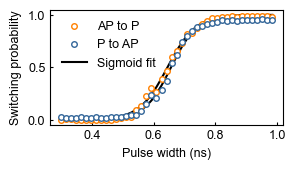

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    # 'xtick.major.pad': 3,
    # 'ytick.major.pad': 3,
})

def sigmoid(x, x0, k):
    return 1 / (1 + np.exp(-k * (x - x0)))

data = np.load("./data/Fig2/Psw_PulseWidth.npy")
PW = data[0]
Psw_APP_PAP = [data[1], data[2]]
colors = ["#FF8000", "#336699"]
fig, ax = plt.subplots(figsize=(3.0, 1.5))

for k, Psw in enumerate(Psw_APP_PAP):
    ax.plot(PW, Psw, 'o', markersize=4, markeredgecolor=colors[k], markerfacecolor="white", linewidth=1, label="AP to P" if k==0 else "P to AP", zorder=3)

for k, Psw in enumerate(Psw_APP_PAP):
    popt, pcov = curve_fit(sigmoid, PW, Psw, p0=[np.median(PW), 1])
    y_fit = sigmoid(PW, *popt)
    ax.plot(PW, y_fit, '-', linewidth=1.5, color="k", label="Sigmoid fit" if k==0 else "", zorder=1)

plt.xlabel("Pulse width (ns)")
plt.ylabel("Switching probability")
#ax.set_yticks([0.25, 0.5, 0.75])
plt.legend(loc="best", frameon=False)
# plt.tight_layout()
plt.savefig(f"./plot/Fig2d.svg", bbox_inches='tight',dpi=800)
plt.show()


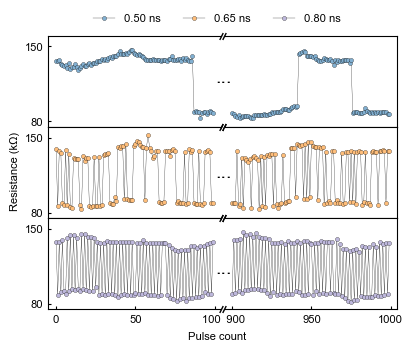

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    # 'xtick.major.pad': 3,
    # 'ytick.major.pad': 3,
})

plot_num = 200
mid = plot_num // 2
color_list = ['#82B0D2', '#FFBE7A', '#BEB8DC']
label_list = ["0.50 ns", "0.65 ns", "0.80 ns"]

r_plot = np.load("./data/Fig2/Resistance_PulseCount.npy")
indices = np.concatenate([np.arange(mid), np.arange(1000-mid, 1000)])
fig, axes = plt.subplots(3, 2, figsize=(4.5, 3.55), gridspec_kw={'wspace': 0.02, 'hspace': 0})
for i in range(3):
    axes[i,0].plot(indices[0:mid],r_plot[i,0:mid],color="k",lw=0.2,marker="o",markersize=3,markerfacecolor=color_list[i],markeredgecolor="k",markeredgewidth=0.2,label=label_list[i])
    R_P = np.min(r_plot) + 3
    R_AP = np.max(r_plot) - 3
    axes[i,0].set_ylim(75,160)
    axes[i,0].set_yticks([80,150])
    axes[i,0].tick_params(labelsize=8,direction='in')
    if i != 2:
        axes[i,0].set_xticks([])
    else:
        axes[i,0].set_xticks([0,50,100])
        axes[i,0].set_xticklabels(['0', '50', '100  '])
    axes[i,1].plot(indices[mid:plot_num],r_plot[i,mid:plot_num],marker="o",color="k",lw=0.2,markersize=3,markerfacecolor=color_list[i],markeredgecolor="k",markeredgewidth=0.2)
    axes[i,1].set_ylim(75,160)
    axes[i,1].tick_params(left=False, labelleft=False,labelsize=8,direction='in')
    if i != 2:
        axes[i,1].set_xticks([])
    else:
        axes[i,1].set_xticks([900,950,1000])
        axes[i,1].set_xticklabels(['  900', '950', '1000'])
    axes[i,0].spines['right'].set_visible(False)
    axes[i,1].spines['left'].set_visible(False)
    # 添加“断裂”标志 (y 轴连接处)
    kwargs = dict(marker=[(-0.5, -1), (0.5, 1)], markersize=5,
                linestyle='none', color='k', mec='k', mew=1, clip_on=False)
    axes[i,0].plot([1], [0], transform=axes[i,0].transAxes, **kwargs)
    axes[i,1].plot([0], [0], transform=axes[i,1].transAxes, **kwargs)
    axes[i,0].plot([1], [1], transform=axes[i,0].transAxes, **kwargs)
    axes[i,1].plot([0], [1], transform=axes[i,1].transAxes, **kwargs)

fig.supylabel('Resistance (kΩ)', fontsize=8, x=0.04)
fig.supxlabel('Pulse count', fontsize=8, y=0.02)

fig.text(0.515, 0.21, '...', ha='center', fontsize=14)
fig.text(0.515, 0.48, '...', ha='center', fontsize=14)
fig.text(0.515, 0.75, '...', ha='center', fontsize=14)

fig.legend(loc="upper center",bbox_to_anchor=(0.5, 0.97),fontsize=8, frameon=False, ncol=3)
plt.savefig("./plot/Fig2e.svg", bbox_inches='tight',dpi=800)
plt.show()